Comparing with SMC-ABC

In [37]:
%pip install pyabc numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [38]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import pyabc
import matplotlib.pyplot as plt
from pyabc.visualization import plot_kde_matrix, plot_epsilons
from pyabc.sampler import SingleCoreSampler


In [79]:
# ==========================================
# 1. Real Data Loading
# ==========================================
import pandas as pd
import numpy as np
import os
import tempfile

# Load your collected sensor data here. 
#file_path = './data/sequence_2/sequence_2_timeseries.csv'
file_path = './data/sequence_2/sequence_3_timeseries.csv'
min_time = 20.0  # Cutoff time from main.ipynb

try:
    df_data = pd.read_csv(file_path)
    
    # --- Minimum Time Filter (from main.ipynb) ---
    original_len = len(df_data)
    df_data = df_data[df_data['relative_time_sec'] >= min_time].copy()
    print(f"Time trim: Removed {original_len - len(df_data)} frames prior to t={min_time:.2f}s")
    
    # Extract arrays
    time_steps = df_data['relative_time_sec'].values
    sensor_data = df_data['max_temperature_kelvin'].values
    
    # CRITICAL: Shift the time series so it starts at t=0
    # This ensures newtons_cooling() correctly uses T0 at the first time step
    time_steps = time_steps - time_steps[0]
    
    print(f"Successfully loaded {len(time_steps)} data points.")
except FileNotFoundError:
    print(f"Warning: '{file_path}' not found. Generating a dummy dataset so the script can run.")

# Set the initial temperature to the very first sensor reading (after the trim)
T0 = sensor_data[0]

# --- NEW NORMALIZATION CODE ---
# Calculate scaling constants from the observed data
data_mean = np.mean(sensor_data)
data_std = np.std(sensor_data)

# Normalize the observed data
sensor_data_norm = (sensor_data - data_mean) / data_std

# The updated mathematical equation with a t_0 shift
#def newtons_cooling(k, T_env, t, t_0, T_initial):
#    return T_env + (T_initial - T_env) * np.exp(-k * (t - t_0))

# Without t_0
def newtons_cooling(k, T_env, t, T_initial):
    """Newton's Law of Cooling assuming the recording starts at t=0"""
    return T_env + (T_initial - T_env) * np.exp(-k * t)

# Package the real observations for pyabc
observation = {"temperature_curve": sensor_data_norm}

In [80]:
# ==========================================
# 2. SMC-ABC Configuration
# ==========================================
prior = pyabc.Distribution(
    k=pyabc.RV("uniform", 0.03, 0.05),
    T_env=pyabc.RV("uniform", 300.0, 310.0),
    #t_0=pyabc.RV("uniform", -5.0, 5.0),
    sigma=pyabc.RV("uniform", 0.1, 5.0), # Search for sensor noise between 0.1 and 5 degrees
    T_initial=pyabc.RV("uniform", 300.0, 350.0)
)

'''
def newtons_cooling(k, T_env, t, t_0, T_initial):
    """Newton's Law of Cooling with a time offset (t_0)"""
    return T_env + (T_initial - T_env) * np.exp(-k * (t - t_0))

'''

def newtons_cooling(k, T_env, t, T_initial):
    """Newton's Law of Cooling assuming the recording starts at t=0"""
    return T_env + (T_initial - T_env) * np.exp(-k * t)

'''
def abc_model(parameters):
    k_sim = parameters["k"]
    T_env_sim = parameters["T_env"]
    t_0_sim = parameters["t_0"]
    sigma_sim = parameters["sigma"]

    clean_curve = newtons_cooling(k_sim, T_env_sim, time_steps, t_0_sim, T0)

    # The model now outputs noisy synthetic data
    noisy_curve = clean_curve + np.random.normal(0, sigma_sim, size=len(time_steps))

    # --- NEW NORMALIZATION CODE ---
    # Normalize the simulated data using the OBSERVED mean and std
    noisy_curve_norm = (noisy_curve - data_mean) / data_std

    return {"temperature_curve": noisy_curve_norm}
'''
# Without t_0
def abc_model(parameters):
    k_sim = parameters["k"]
    T_env_sim = parameters["T_env"]
    sigma_sim = parameters["sigma"]
    T_initial_sim = parameters["T_initial"] 
    # t_0_sim is completely gone

    # Generate the curve using the fixed function
    clean_curve = newtons_cooling(k_sim, T_env_sim, time_steps, T_initial_sim)

    # Add the simulated noise
    noisy_curve = clean_curve + np.random.normal(0, sigma_sim, size=len(time_steps))

    # Normalize the simulated data (using constants calculated from your sensor data)
    noisy_curve_norm = (noisy_curve - data_mean) / data_std

    # Return the normalized curve
    return {"temperature_curve": noisy_curve_norm}

In [85]:
# ==========================================
# 3. Execution (Fixed for Jupyter)
# ==========================================
# This is the line where we initialize ABCSMC and add the SingleCoreSampler
# Use an adaptive distance metric to prevent early steep drops from dominating

from pyabc.sampler import SingleCoreSampler

distance = pyabc.AdaptivePNormDistance(p=2)

abc = pyabc.ABCSMC(
    models=abc_model,
    parameter_priors=prior,
    distance_function=distance,
    population_size=pyabc.ConstantPopulationSize(200),
    sampler=SingleCoreSampler()
)

# Setup database logging
db_path = "sqlite:///" + os.path.join(tempfile.gettempdir(), "thermal_abc.db")

# Initialize and run
abc.new(db_path, observation)
print("Starting ABC-SMC run...")
history = abc.run(minimum_epsilon=0.5, max_nr_populations=25)
print("ABC-SMC run completed.")

ABC.History INFO: Start <ABCSMC id=10, start_time=2026-07-20 16:45:43>
ABC INFO: Calibration sample t = -1.
ABC.Population INFO: Recording also rejected particles: True
ABC INFO: t: 0, eps: 1.12813063e+01.


Starting ABC-SMC run...


ABC INFO: Accepted: 200 / 415 = 4.8193e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 7.98933099e+00.
ABC INFO: Accepted: 200 / 417 = 4.7962e-01, ESS: 1.2535e+02.
ABC INFO: t: 2, eps: 8.66093679e+00.
ABC INFO: Accepted: 200 / 388 = 5.1546e-01, ESS: 1.4998e+02.
ABC INFO: t: 3, eps: 1.06279681e+01.
ABC INFO: Accepted: 200 / 395 = 5.0633e-01, ESS: 1.5970e+02.
ABC INFO: t: 4, eps: 9.63585147e+00.
ABC INFO: Accepted: 200 / 391 = 5.1151e-01, ESS: 4.3625e+01.
ABC INFO: t: 5, eps: 8.44799107e+00.
ABC INFO: Accepted: 200 / 391 = 5.1151e-01, ESS: 1.2764e+02.
ABC INFO: t: 6, eps: 7.39844172e+00.
ABC INFO: Accepted: 200 / 419 = 4.7733e-01, ESS: 1.3929e+02.
ABC INFO: t: 7, eps: 6.83442407e+00.
ABC INFO: Accepted: 200 / 421 = 4.7506e-01, ESS: 1.5371e+02.
ABC INFO: t: 8, eps: 5.91321080e+00.
ABC INFO: Accepted: 200 / 473 = 4.2283e-01, ESS: 1.5632e+02.
ABC INFO: t: 9, eps: 5.96773531e+00.
ABC INFO: Accepted: 200 / 423 = 4.7281e-01, ESS: 1.1944e+02.
ABC INFO: t: 10, eps: 5.71372449e+00.
ABC INFO: Accepted:

ABC-SMC run completed.


In [82]:
def mode(arr):
    """Compute the mode of an array."""

    vals, counts = np.unique(arr, return_counts=True)
    mode_value = vals[np.argmax(counts)]

    return mode_value

In [83]:
import matplotlib.pyplot as plt
import numpy as np

def plot_posterior_predictive(history, t_real, temp_real, T0, num_samples=200):
    df, w = history.get_distribution(m=0, t=history.max_t)
    sample_indices = np.random.choice(len(df), size=num_samples, p=w)
    
    plt.figure(figsize=(10, 6))
    
    first_curve = True
    for idx in sample_indices:
        row = df.iloc[idx]
        k_sample = row['k']
        T_env_sample = row['T_env']
        t_0_sample = row['t_0']  # Extract the learned time offset
        
        # Run the model with the time shift
        temp_pred = newtons_cooling(k_sample, T_env_sample, t_real, t_0_sample, T0)

        if first_curve:
            plt.plot(t_real, temp_pred, color='dodgerblue', alpha=0.05, label='Posterior Predictive')
            first_curve = False
        else:
            plt.plot(t_real, temp_pred, color='dodgerblue', alpha=0.05)
            
    plt.scatter(t_real, temp_real, color='black', s=15, zorder=5, label='Real Sensor Data')
    
    # Plot the mean curve
    k_mean = np.average(df['k'], weights=w)
    T_env_mean = np.average(df['T_env'], weights=w)
    #t_0_mean = np.average(df['t_0'], weights=w)
    T_0_mean = np.average(df['T_initial'], weights=w)
    sigma_mean = np.average(df['sigma'], weights=w)
    temp_mean = newtons_cooling(k_mean, T_env_mean, t_real, t_0_mean, T0)
    print("k_mean:", k_mean)
    print("T_env_mean:", T_env_mean)
    print("t_0_mean:", t_0_mean)
    print("T_0_mean:", T_0_mean)
    print("sigma_mean:", sigma_mean)

    k_mode = mode(df['k'])
    T_env_mode = mode(df['T_env'])
    t_0_mode = mode(df['t_0']) 
    T_0_mode = mode(df['T_initial'])
    sigma_mode = mode(df['sigma'])

    print("k_mode:", k_mode)
    print("T_env_mode:", T_env_mode)
    print("t_0_mode:", t_0_mode)
    print("T_0_mode:", T_0_mode)
    print("sigma_mode:", sigma_mode)
    
    plt.plot(t_real, temp_mean, color='red', linestyle='--', linewidth=2, 
             label=f'Mean Model (t_0={t_0_mean:.2f}s)', zorder=6)
    
    plt.title("Posterior Predictive Check with Time Offset ($t_0$)", fontsize=14)
    plt.xlabel("Time (seconds)", fontsize=12)
    plt.ylabel("Temperature (Kelvin)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

In [84]:
plot_posterior_predictive(history, time_steps, sensor_data, T0, num_samples=100)

KeyError: 't_0'

<Figure size 1000x600 with 0 Axes>

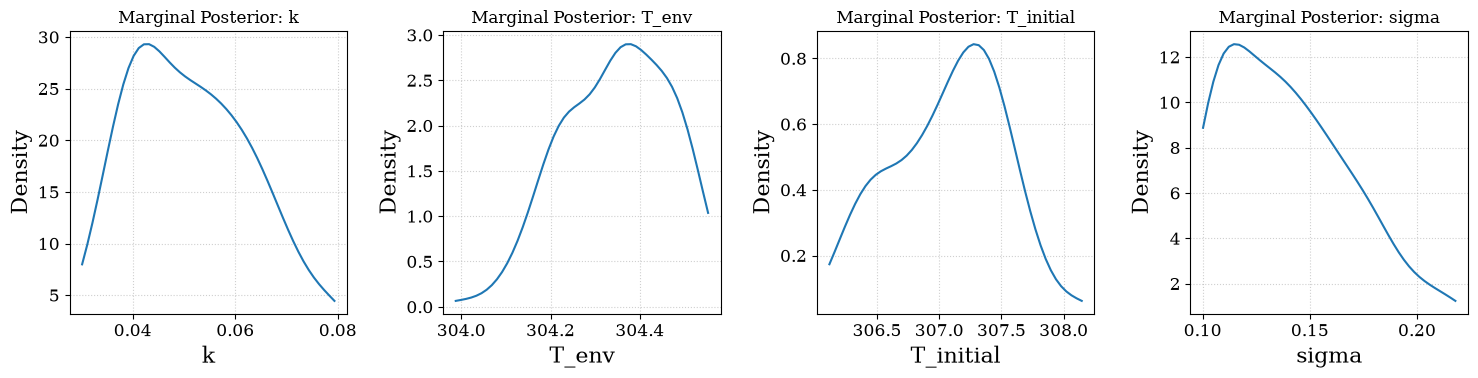

In [86]:
'''
from pyabc.visualization import plot_kde_1d

def plot_homoscedastic_marginals(history):
    df_params, w = history.get_distribution(m=0, t=history.max_t)
    
    params = ["k", "T_env", "t_0", "T_initial"]
    
    # Create a 1x3 grid
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    
    for i, param in enumerate(params):
        plot_kde_1d(df_params, w, x=param, ax=axes[i])
        axes[i].set_title(f"Marginal Posterior: {param}", fontsize=12)
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].set_ylabel("Density")
        
    plt.tight_layout()
    plt.show()

# Execute using your existing history object
plot_homoscedastic_marginals(history)
'''

def plot_homoscedastic_marginals(history):
    df_params, w = history.get_distribution(m=0, t=history.max_t)
    
    # Removed "t_0" from this list
    params = ["k", "T_env", "T_initial", "sigma"] 
    
    fig, axes = plt.subplots(1, len(params), figsize=(15, 4))
    
    for i, param in enumerate(params):
        plot_kde_1d(df_params, w, x=param, ax=axes[i])
        axes[i].set_title(f"Marginal Posterior: {param}", fontsize=12)
        axes[i].grid(True, linestyle=':', alpha=0.6)
        axes[i].set_ylabel("Density")
        
    plt.tight_layout()
    plt.show()

plot_homoscedastic_marginals(history)

Publication ready plots:

loading both data

In [103]:
import os
import pandas as pd
import numpy as np

def load_and_preprocess_timeseries(file_path, min_time, metric='max_temperature_kelvin'):
    """
    Loads data, filters by minimum time, removes outliers via IQR, 
    and returns normalized arrays for SBI.
    """
    try:
        df = pd.read_csv(file_path)
        
        # 1. Filter by minimum time
        if min_time > 0:
            original_len = len(df)
            df = df[df['relative_time_sec'] >= min_time].copy()
            print(f"[{file_path}] Trimmed {original_len - len(df)} frames prior to t={min_time:.2f}s")
        
        # 2. IQR method for outlier removal
        Q1 = df[metric].quantile(0.25)
        Q3 = df[metric].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean = df[(df[metric] >= lower_bound) & (df[metric] <= upper_bound)].copy()
        outliers_removed = len(df) - len(df_clean)
        print(f"[{file_path}] Removed {outliers_removed} outliers using IQR.")

        # 3. Extract physical arrays and force float64
        time_steps = df_clean['relative_time_sec'].values.astype(np.float64)
        sensor_data = df_clean[metric].values.astype(np.float64)
        
        # 4. Shift time to start at t=0
        time_steps = time_steps - time_steps[0]
        T0 = sensor_data[0]
        
        # 5. Normalization
        data_mean = np.mean(sensor_data)
        data_std = np.std(sensor_data)
        sensor_data_norm = (sensor_data - data_mean) / data_std
        
        return time_steps, sensor_data, sensor_data_norm, data_mean, data_std, T0
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None, None, None, None, None, None


# Load Profile A
file_path_A = './data/sequence_2/sequence_2_timeseries.csv'
min_time_A = 20.0  
t_real_A, temp_real_A, temp_norm_A, mean_A, std_A, T0_A = load_and_preprocess_timeseries(file_path_A, min_time_A)

# Load Profile B
file_path_B = './data/sequence_3/sequence_3_timeseries.csv'
min_time_B = 20.0  
t_real_B, temp_real_B, temp_norm_B, mean_B, std_B, T0_B = load_and_preprocess_timeseries(file_path_B, min_time_B)

# Package normalized observations for PyABC
observation_A = {"temperature_curve": temp_norm_A}
observation_B = {"temperature_curve": temp_norm_B}

[./data/sequence_2/sequence_2_timeseries.csv] Trimmed 3 frames prior to t=20.00s
[./data/sequence_2/sequence_2_timeseries.csv] Removed 1 outliers using IQR.
[./data/sequence_3/sequence_3_timeseries.csv] Trimmed 2 frames prior to t=20.00s
[./data/sequence_3/sequence_3_timeseries.csv] Removed 3 outliers using IQR.


In [104]:
import tempfile
import pyabc
from pyabc.sampler import SingleCoreSampler

def newtons_cooling(k, T_env, t, T_initial):
    """Newton's Law of Cooling assuming the recording starts at t=0"""
    return T_env + (T_initial - T_env) * np.exp(-k * t)

# Define parameter priors
prior = pyabc.Distribution(
    k=pyabc.RV("uniform", 0.03, 0.05),
    T_env=pyabc.RV("uniform", 300.0, 310.0),
    #t_0=pyabc.RV("uniform", -5.0, 5.0),
    sigma=pyabc.RV("uniform", 0.1, 5.0), # Search for sensor noise between 0.1 and 5 degrees
    T_initial=pyabc.RV("uniform", 300.0, 350.0)
)

def create_model_for_sequence(time_array, obs_mean, obs_std):
    """
    Returns a PyABC model bound to a specific sequence's time array
    and normalization constants.
    """
    def abc_model(parameters):
        k_sim = parameters["k"]
        T_env_sim = parameters["T_env"]
        T_initial_sim = parameters["T_initial"] 
        sigma_sim = parameters["sigma"]
        
        # 1. Generate physical curve
        clean_curve = newtons_cooling(k_sim, T_env_sim, time_array, T_initial_sim)
        
        # 2. Add physical noise
        noisy_curve = clean_curve + np.random.normal(0, sigma_sim, size=len(time_array))
        
        # 3. Normalize using the OBSERVED mean and std
        noisy_curve_norm = (noisy_curve - obs_mean) / obs_std
        
        return {"temperature_curve": noisy_curve_norm}
        
    return abc_model

def run_thermal_abc(observation_data, time_array, obs_mean, obs_std, db_filename):
    """
    Runs the ABC-SMC algorithm using normalized data metrics.
    """
    distance = pyabc.AdaptivePNormDistance(p=2)
    
    # Instantiate normalized model
    specific_abc_model = create_model_for_sequence(time_array, obs_mean, obs_std)

    abc = pyabc.ABCSMC(
        models=specific_abc_model,
        parameter_priors=prior,
        distance_function=distance,
        population_size=pyabc.ConstantPopulationSize(200),
        sampler=SingleCoreSampler()
    )

    db_path = "sqlite:///" + os.path.join(tempfile.gettempdir(), db_filename)
    print(f"Initializing ABC-SMC run -> {db_filename}")
    
    abc.new(db_path, observation_data)
    history = abc.run(minimum_epsilon=0.5, max_nr_populations=20)
    
    print(f"Run completed. Data saved to {db_path}\n")
    return history

# ==========================================
# 3. Execute Inference
# ==========================================

print("--- Starting Inference for Profile A ---")
history_A = run_thermal_abc(
    observation_data=observation_A, 
    time_array=t_real_A, 
    obs_mean=mean_A, 
    obs_std=std_A, 
    db_filename="thermal_abc_sequence_1.db"
)

print("--- Starting Inference for Profile B ---")
history_B = run_thermal_abc(
    observation_data=observation_B, 
    time_array=t_real_B, 
    obs_mean=mean_B, 
    obs_std=std_B, 
    db_filename="thermal_abc_sequence_2.db"
)

ABC.History INFO: Start <ABCSMC id=8, start_time=2026-07-20 17:01:42>
ABC INFO: Calibration sample t = -1.
ABC.Population INFO: Recording also rejected particles: True
ABC INFO: t: 0, eps: 1.01271063e+01.


--- Starting Inference for Profile A ---
Initializing ABC-SMC run -> thermal_abc_sequence_1.db


ABC INFO: Accepted: 200 / 420 = 4.7619e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 8.04410215e+00.
ABC INFO: Accepted: 200 / 427 = 4.6838e-01, ESS: 1.5745e+02.
ABC INFO: t: 2, eps: 9.97224848e+00.
ABC INFO: Accepted: 200 / 437 = 4.5767e-01, ESS: 1.4876e+02.
ABC INFO: t: 3, eps: 9.30638227e+00.
ABC INFO: Accepted: 200 / 520 = 3.8462e-01, ESS: 1.0775e+02.
ABC INFO: t: 4, eps: 8.94095892e+00.
ABC INFO: Accepted: 200 / 460 = 4.3478e-01, ESS: 1.4807e+02.
ABC INFO: t: 5, eps: 9.17315789e+00.
ABC INFO: Accepted: 200 / 436 = 4.5872e-01, ESS: 9.7072e+01.
ABC INFO: t: 6, eps: 7.89144945e+00.
ABC INFO: Accepted: 200 / 408 = 4.9020e-01, ESS: 1.4348e+02.
ABC INFO: t: 7, eps: 6.45934444e+00.
ABC INFO: Accepted: 200 / 443 = 4.5147e-01, ESS: 1.3505e+02.
ABC INFO: t: 8, eps: 6.75487846e+00.
ABC INFO: Accepted: 200 / 377 = 5.3050e-01, ESS: 7.1349e+01.
ABC INFO: t: 9, eps: 6.79459081e+00.
ABC INFO: Accepted: 200 / 351 = 5.6980e-01, ESS: 1.5701e+02.
ABC INFO: t: 10, eps: 6.55583143e+00.
ABC INFO: Accepted:

Run completed. Data saved to sqlite:////tmp/thermal_abc_sequence_1.db

--- Starting Inference for Profile B ---
Initializing ABC-SMC run -> thermal_abc_sequence_2.db


ABC INFO: Accepted: 200 / 435 = 4.5977e-01, ESS: 2.0000e+02.
ABC INFO: t: 1, eps: 5.72613695e+00.
ABC INFO: Accepted: 200 / 427 = 4.6838e-01, ESS: 1.6460e+02.
ABC INFO: t: 2, eps: 8.12726363e+00.
ABC INFO: Accepted: 200 / 491 = 4.0733e-01, ESS: 1.5507e+02.
ABC INFO: t: 3, eps: 7.86044156e+00.
ABC INFO: Accepted: 200 / 454 = 4.4053e-01, ESS: 9.6543e+01.
ABC INFO: t: 4, eps: 8.36368351e+00.
ABC INFO: Accepted: 200 / 439 = 4.5558e-01, ESS: 1.4343e+02.
ABC INFO: t: 5, eps: 6.63692499e+00.
ABC INFO: Accepted: 200 / 442 = 4.5249e-01, ESS: 1.5050e+02.
ABC INFO: t: 6, eps: 6.76510518e+00.
ABC INFO: Accepted: 200 / 420 = 4.7619e-01, ESS: 1.5390e+02.
ABC INFO: t: 7, eps: 5.89471048e+00.
ABC INFO: Accepted: 200 / 460 = 4.3478e-01, ESS: 1.0479e+02.
ABC INFO: t: 8, eps: 5.53786139e+00.
ABC INFO: Accepted: 200 / 434 = 4.6083e-01, ESS: 1.3743e+02.
ABC INFO: t: 9, eps: 5.39256001e+00.
ABC INFO: Accepted: 200 / 418 = 4.7847e-01, ESS: 1.3160e+02.
ABC INFO: t: 10, eps: 5.21057939e+00.
ABC INFO: Accepted:

Run completed. Data saved to sqlite:////tmp/thermal_abc_sequence_2.db



plotting

In [105]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Assumes these functions are defined elsewhere in your script:
# from your_module import newtons_cooling, plot_kde_1d

def plot_comparative_sbi_analysis(history_A, history_B, 
                                  t_real_A, temp_real_A, 
                                  t_real_B, temp_real_B, 
                                  ground_truth_A=None, ground_truth_B=None,
                                  num_samples=1000, 
                                  save_dir="."):
    """
    Generates a composite figure comparing two thermal decay profiles.
    Top row: Split posterior predictive checks.
    Bottom row: Shared parameter marginal distributions.
    """
    
    # 1. Publication-ready typography and styling
    plt.rcParams.update({
        'font.size': 14,
        'font.family': 'serif', 
        'axes.labelsize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })
    
    # 2. Extract the final distributions from both ABC histories
    df_A, w_A = history_A.get_distribution(m=0, t=history_A.max_t)
    df_B, w_B = history_B.get_distribution(m=0, t=history_B.max_t)
    
    # 3. Initialize the GridSpec layout
    fig = plt.figure(figsize=(16, 9))
    gs = GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.3)
    
    # ==========================================
    # TOP ROW: Split Posterior Predictives
    # ==========================================
    
    def plot_predictive(ax, df, w, t_real, temp_real, title, color_fit, color_data):
        # Sample parameter sets
        sample_indices = np.random.choice(len(df), size=num_samples, p=w)
        simulated_trajectories = np.zeros((num_samples, len(t_real)))
        
        for idx, row_idx in enumerate(sample_indices):
            row = df.iloc[row_idx]
            k_sample = row['k']
            T_env_sample = row['T_env']
            T0_sample = row['T_initial']
            
            # Simulate forward (t_0 shift is handled during preprocessing)
            simulated_trajectories[idx, :] = newtons_cooling(k_sample, T_env_sample, t_real, T0_sample)
            
        # Calculate percentiles
        median_pred = np.percentile(simulated_trajectories, 50, axis=0)
        lower_95 = np.percentile(simulated_trajectories, 2.5, axis=0)
        upper_95 = np.percentile(simulated_trajectories, 97.5, axis=0)
        lower_68 = np.percentile(simulated_trajectories, 16, axis=0)
        upper_68 = np.percentile(simulated_trajectories, 84, axis=0)
        
        # Plot Bands and Median
        ax.fill_between(t_real, lower_95, upper_95, color=color_fit, alpha=0.15, edgecolor='none')
        ax.fill_between(t_real, lower_68, upper_68, color=color_fit, alpha=0.3, edgecolor='none')
        ax.plot(t_real, median_pred, color=color_fit, linewidth=2, label='Median Prediction')
        
        # Overlay Real Data
        ax.scatter(t_real, temp_real, color=color_data, alpha=0.6, s=30, edgecolors='none', label='Sensor Data', zorder=5)
        
        # Aesthetics
        ax.set_title(title, fontsize=16, pad=10)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Temperature (K)")
        ax.legend(loc='upper right', frameon=False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle=':', alpha=0.4, color='gray')

    # Assign left columns (0, 1) to Profile A and right columns (2, 3) to Profile B
    ax_pred_A = fig.add_subplot(gs[0, 0:2])
    plot_predictive(ax_pred_A, df_A, w_A, t_real_A, temp_real_A, 
                    "Posterior Predictive: Profile A", '#93003a', '#00429d')
    
    ax_pred_B = fig.add_subplot(gs[0, 2:4])
    plot_predictive(ax_pred_B, df_B, w_B, t_real_B, temp_real_B, 
                    "Posterior Predictive: Profile B", '#d45087', '#00798c')
    
    # ==========================================
    # BOTTOM ROW: Shared Marginal Posteriors
    # ==========================================
    params = ["k", "T_env", "T_initial", "sigma"] 
    
    for i, param in enumerate(params):
        ax_marg = fig.add_subplot(gs[1, i])
        
        # Plot KDE for Profile A
        plot_kde_1d(df_A, w_A, x=param, ax=ax_marg)
        lines = ax_marg.get_lines()
        if len(lines) > 0:
            line_A = lines[-1]
            line_A.set_color('#00429d')
            line_A.set_linewidth(2)
            line_A.set_label('Profile A')
            
        # Plot KDE for Profile B
        plot_kde_1d(df_B, w_B, x=param, ax=ax_marg)
        lines = ax_marg.get_lines()
        if len(lines) > 1:
            line_B = lines[-1]
            line_B.set_color('#00798c')
            line_B.set_linewidth(2)
            line_B.set_label('Profile B')
            
        # Optional: Add ground truth vertical lines if dictionaries are provided
        if ground_truth_A and param in ground_truth_A:
            ax_marg.axvline(ground_truth_A[param], color='#00429d', linestyle=':', linewidth=2, alpha=0.7)
        if ground_truth_B and param in ground_truth_B:
            ax_marg.axvline(ground_truth_B[param], color='#00798c', linestyle=':', linewidth=2, alpha=0.7)
            
        # Aesthetics for marginals
        ax_marg.set_title(f"Marginal: {param}", fontsize=14)
        ax_marg.spines['top'].set_visible(False)
        ax_marg.spines['right'].set_visible(False)
        ax_marg.grid(True, linestyle=':', alpha=0.4, color='gray')
        
        if i == 0:
            ax_marg.set_ylabel("Density")
            ax_marg.legend(loc='best', frameon=False, fontsize=10)
        else:
            ax_marg.set_ylabel("") # Remove redundant y-labels
            
    # ==========================================
    # Finalization and Export
    # ==========================================
    plt.tight_layout()
    
    # Ensure export directory exists
    os.makedirs(save_dir, exist_ok=True)
    
    # Export as PDF and SVG for high-quality typesetting integration
    pdf_path = os.path.join(save_dir, "comparative_sbi_analysis.pdf")
    svg_path = os.path.join(save_dir, "comparative_sbi_analysis.svg")
    
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    plt.savefig(svg_path, format='svg', bbox_inches='tight')
    
    print(f"Plots saved successfully to:\n- {pdf_path}\n- {svg_path}")
    plt.show()

/tmp/ipykernel_4499/2539890138.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


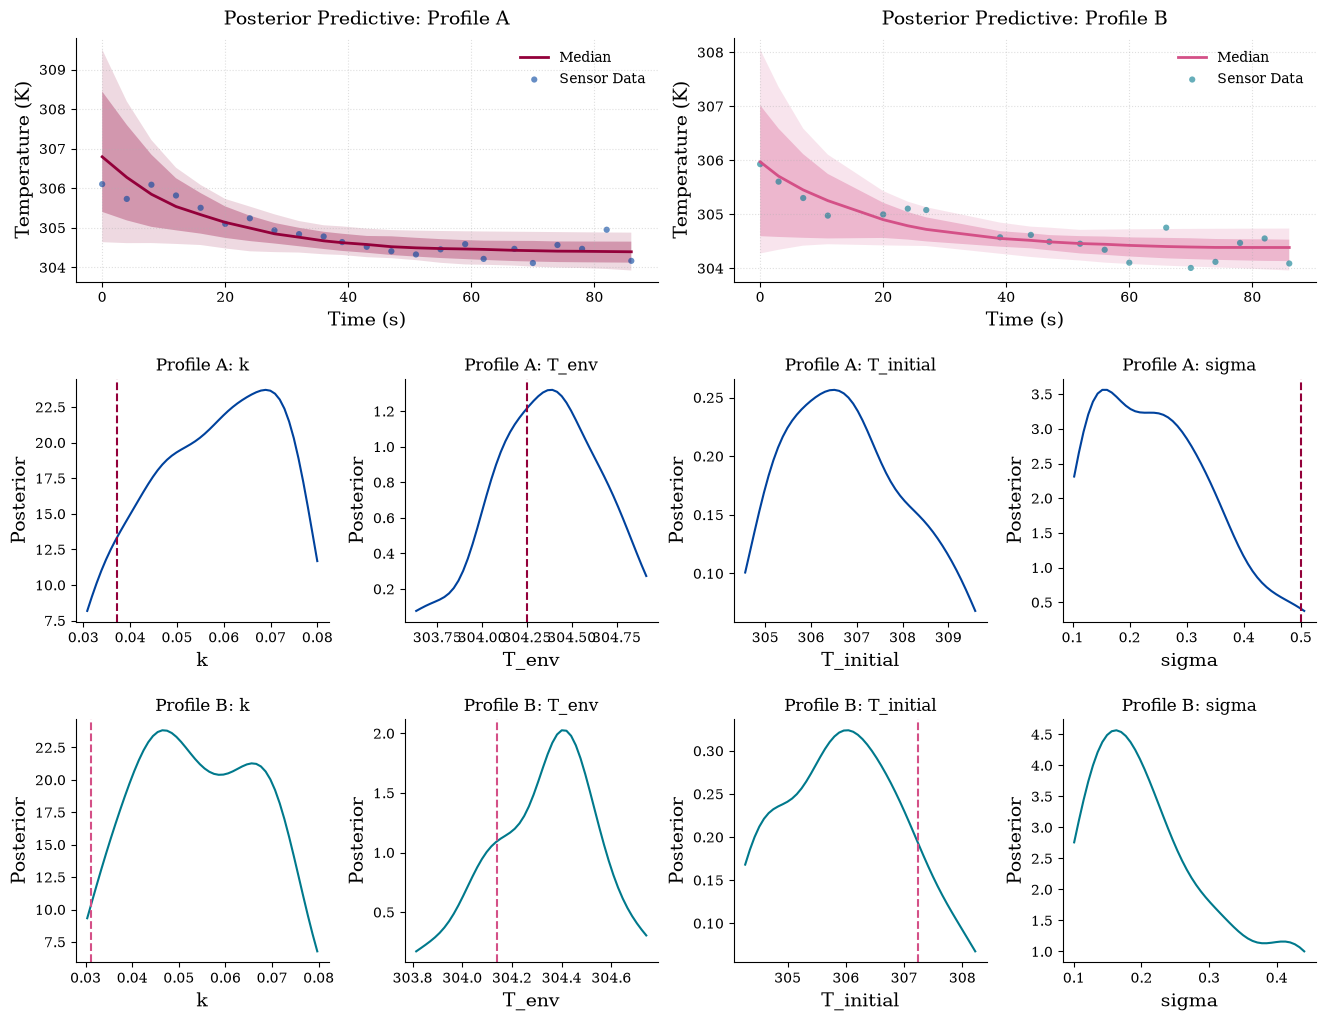

In [109]:
# 1. Define ground truth dictionaries if you have regression baseline values.
# (If you don't want vertical lines on the marginals, you can omit these or pass None).
regression_values_A = {
    "k": 0.03719,         # Replace with actual regression result for Profile A
    "T_env": 304.25,     # Replace with actual regression result for Profile A
    "T_initial": 6.40+304.25,  # Replace with actual regression result for Profile A
    "sigma": 0.5         # Replace with actual regression result for Profile A
}

regression_values_B = {
    "k": 0.03113,         # Replace with actual regression result for Profile B
    "T_env": 304.14,     # Replace with actual regression result for Profile B
    "T_initial": 3.10+304.14,  # Replace with actual regression result for Profile B
    "sigma": 0.5         # Replace with actual regression result for Profile B
}


# 2. Execute the comparative plotting function
plot_comparative_sbi_analysis(
    history_A=history_A,          # Your PyABC history object for Sequence 1
    history_B=history_B,          # Your PyABC history object for Sequence 2
    t_real_A=t_real_A,            # Loaded from load_and_preprocess_timeseries
    temp_real_A=temp_real_A,      # Loaded from load_and_preprocess_timeseries
    t_real_B=t_real_B,            # Loaded from load_and_preprocess_timeseries
    temp_real_B=temp_real_B,      # Loaded from load_and_preprocess_timeseries
    ground_truth_A=regression_values_A, 
    ground_truth_B=regression_values_B,
    num_samples=1000,
    save_dir="./plots"            # Output directory for your Typst-ready PDFs/SVGs
)

In [107]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_comparative_sbi_analysis(history_A, history_B, 
                                  t_real_A, temp_real_A, 
                                  t_real_B, temp_real_B, 
                                  ground_truth_A=None, ground_truth_B=None,
                                  num_samples=1000, 
                                  save_dir="."):
    """
    Generates a composite figure:
    Top row: Split posterior predictive checks.
    Middle row: Marginal posteriors for Profile A.
    Bottom row: Marginal posteriors for Profile B.
    """
    
    # 1. Typography and styling
    plt.rcParams.update({
        'font.size': 12, # Slightly smaller for 3-row density
        'font.family': 'serif', 
        'axes.labelsize': 14,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
    })
    
    # Extract distributions
    df_A, w_A = history_A.get_distribution(m=0, t=history_A.max_t)
    df_B, w_B = history_B.get_distribution(m=0, t=history_B.max_t)
    
    # 2. Initialize GridSpec (3 rows, 4 columns)
    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.3)
    
    # --- TOP ROW: Posterior Predictives ---
    def plot_predictive(ax, df, w, t_real, temp_real, title, color_fit, color_data):
        sample_indices = np.random.choice(len(df), size=num_samples, p=w)
        simulated_trajectories = np.zeros((num_samples, len(t_real)))
        
        for idx, row_idx in enumerate(sample_indices):
            row = df.iloc[row_idx]
            simulated_trajectories[idx, :] = newtons_cooling(row['k'], row['T_env'], t_real, row['T_initial'])
            
        median_pred = np.percentile(simulated_trajectories, 50, axis=0)
        lower_95, upper_95 = np.percentile(simulated_trajectories, [2.5, 97.5], axis=0)
        lower_68, upper_68 = np.percentile(simulated_trajectories, [16, 84], axis=0)
        
        ax.fill_between(t_real, lower_95, upper_95, color=color_fit, alpha=0.15, edgecolor='none')
        ax.fill_between(t_real, lower_68, upper_68, color=color_fit, alpha=0.3, edgecolor='none')
        ax.plot(t_real, median_pred, color=color_fit, linewidth=2, label='Median')
        ax.scatter(t_real, temp_real, color=color_data, alpha=0.6, s=20, edgecolors='none', label='Sensor Data')
        
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Temperature (K)")
        ax.legend(loc='upper right', frameon=False)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, linestyle=':', alpha=0.4)

    ax_pred_A = fig.add_subplot(gs[0, 0:2])
    plot_predictive(ax_pred_A, df_A, w_A, t_real_A, temp_real_A, "Posterior Predictive: Profile A", '#93003a', '#00429d')
    
    ax_pred_B = fig.add_subplot(gs[0, 2:4])
    plot_predictive(ax_pred_B, df_B, w_B, t_real_B, temp_real_B, "Posterior Predictive: Profile B", '#d45087', '#00798c')
    
    # --- MIDDLE & BOTTOM ROWS: Marginal Posteriors ---
    params = ["k", "T_env", "T_initial", "sigma"] 
    
    for i, param in enumerate(params):
        # Marginal Row A
        ax_marg_A = fig.add_subplot(gs[1, i])
        plot_kde_1d(df_A, w_A, x=param, ax=ax_marg_A)
        ax_marg_A.get_lines()[0].set_color('#00429d')
        if ground_truth_A and param in ground_truth_A:
            ax_marg_A.axvline(ground_truth_A[param], color='#93003a', linestyle='--', linewidth=1.5)
        ax_marg_A.set_title(f"Profile A: {param}", fontsize=12)
        ax_marg_A.spines[['top', 'right']].set_visible(False)
        
        # Marginal Row B
        ax_marg_B = fig.add_subplot(gs[2, i])
        plot_kde_1d(df_B, w_B, x=param, ax=ax_marg_B)
        ax_marg_B.get_lines()[0].set_color('#00798c')
        if ground_truth_B and param in ground_truth_B:
            ax_marg_B.axvline(ground_truth_B[param], color='#d45087', linestyle='--', linewidth=1.5)
        ax_marg_B.set_title(f"Profile B: {param}", fontsize=12)
        ax_marg_B.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(os.path.join(save_dir, "comparative_sbi_analysis.pdf"), format='pdf', bbox_inches='tight')
    plt.show()